In [4]:
### Cell 1：导入库
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt

图片数量统计：
  angry: 3995张
  disgust: 436张
  fear: 4097张
  happy: 7215张
  neutral: 4965张
  sad: 4830张
  surprise: 3171张


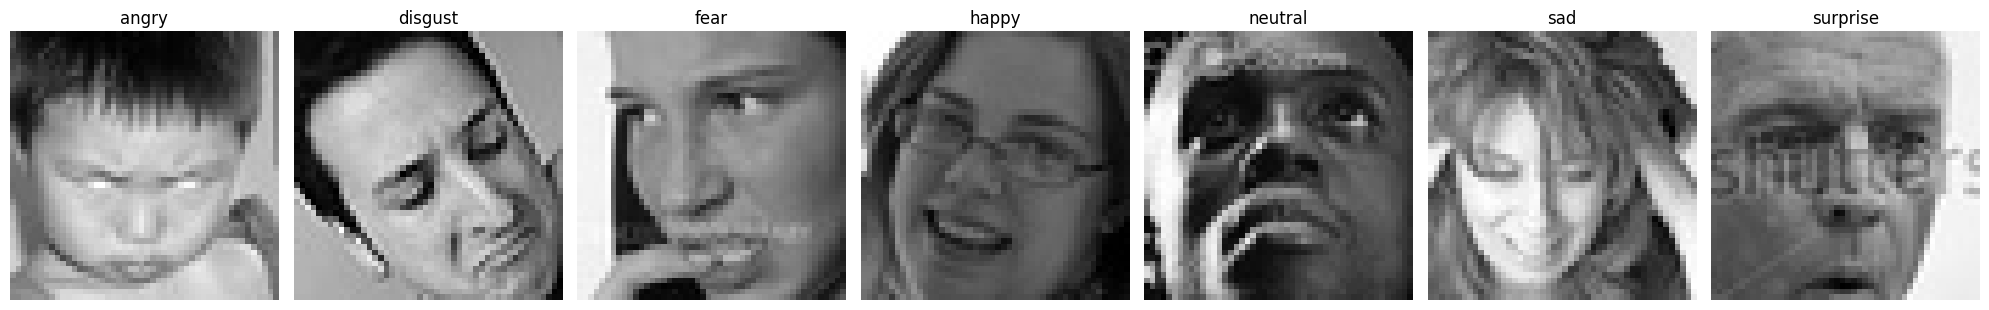

In [5]:
### Cell 2：检查数据
data_path = './data/emotion/train'
emotions = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# 统计每类图片数量
print("图片数量统计：")
for emotion in emotions:
    emotion_path = os.path.join(data_path, emotion)
    if os.path.exists(emotion_path):
        count = len([f for f in os.listdir(emotion_path)
                     if f.endswith(('.jpg', '.png', '.jpeg'))])
        print(f"  {emotion}: {count}张")
    else:
        print(f"  {emotion}: ❌ 文件夹不存在！检查路径")

# 预览每种情绪的第一张图
fig, axes = plt.subplots(1, 7, figsize=(20, 3))
for i, emotion in enumerate(emotions):
    emotion_path = os.path.join(data_path, emotion)
    if os.path.exists(emotion_path):
        files = [f for f in os.listdir(emotion_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
        if files:
            img = Image.open(os.path.join(emotion_path, files[0]))
            axes[i].imshow(img, cmap='gray')
            axes[i].set_title(emotion)
            axes[i].axis('off')
plt.tight_layout()
plt.show()

In [6]:
### Cell 3：数据预处理和加载# === 数据预处理流水线 ===
# 每张图片进来，按这个顺序处理一遍

transform = transforms.Compose([
    transforms.Resize((48, 48)),                   # 统一尺寸为48×48
    transforms.Grayscale(num_output_channels=3),   # 灰度图复制成3通道（ResNet要求）
    transforms.RandomHorizontalFlip(),             # 随机左右翻转（数据增强）
    transforms.ToTensor(),                         # 转成张量，像素值 0-255 → 0-1
    transforms.Normalize([0.5, 0.5, 0.5],          # 标准化到 -1 ~ 1
                         [0.5, 0.5, 0.5])
])

# === 加载数据 ===
# ImageFolder 自动按文件夹名分类：happy/ 里的图标签就是 "happy"

train_dataset = datasets.ImageFolder('./data/emotion/train', transform=transform)
val_dataset = datasets.ImageFolder('./data/emotion/val', transform=transform)

# === 分批加载 ===
# batch_size=32：每次取32张图送进模型
# 为什么不一次全送？28000张图一起塞进显存会爆掉
# shuffle=True：打乱顺序，防止模型记住"第1张是开心，第2张是难过"

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"训练数据: {len(train_dataset)}张，分成{len(train_loader)}批")
print(f"验证数据: {len(val_dataset)}张，分成{len(val_loader)}批")
print(f"类别顺序: {train_dataset.classes}")

训练数据: 28709张，分成898批
验证数据: 7178张，分成225批
类别顺序: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [8]:
### Cell 4：加载模型
# === 加载预训练的 ResNet18 ===
# ResNet18 在 ImageNet（120万张图、1000类）上训练过
# 它已经学会了"边缘、纹理、形状"等通用视觉特征
# 我们不用从零学，直接借用它的能力

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# === 修改最后一层 ===
# 原来：512维特征 → 1000类（ImageNet的1000种物体）
# 改成：512维特征 → 7类（我们的7种情绪）
# 512 是 ResNet18 倒数第二层固定输出的维度，不用改

model.fc = nn.Linear(512, 7)

# === 搬到 GPU ===
# GPU 算矩阵比 CPU 快几十倍

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"模型已加载到: {device}")

模型已加载到: cuda


In [9]:
### Cell 5：训练
# === 准备训练工具 ===

# Adam 优化器：根据每个参数的历史梯度，自动调整学习步长
# lr=0.0001：学习率，控制每次参数更新的幅度
# 微调预训练模型用小学习率，防止破坏已学到的特征
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# 交叉熵损失：分类任务标配
# 衡量"模型预测的概率分布"和"正确答案"之间的差距
criterion = nn.CrossEntropyLoss()

# === 开始训练 ===

num_epochs = 10  # 训练10轮，每轮把所有数据过一遍
best_acc = 0     # 记录最佳验证准确率

print("开始训练...\n")

for epoch in range(num_epochs):

    # --- 训练阶段 ---
    model.train()  # 开启训练模式（启用 Dropout 等）
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)  # 图片搬到 GPU
        labels = labels.to(device)  # 标签搬到 GPU

        # 1. 前向传播：图片经过18层计算，输出7个分数
        outputs = model(images)

        # 2. 算 loss：预测结果和正确答案差多少
        loss = criterion(outputs, labels)

        # 3. 清空上一步的梯度（不清空会累加，更新就乱了）
        optimizer.zero_grad()

        # 4. 反向传播：从 loss 往回算，每个参数对 loss 影响多大
        loss.backward()

        # 5. 更新参数：往 loss 减小的方向走一步
        optimizer.step()

        # 统计准确率
        _, predicted = outputs.max(1)  # 取7个分数中最大的作为预测
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    train_acc = 100. * train_correct / train_total

    # --- 验证阶段 ---
    model.eval()  # 关闭训练模式，预测更稳定
    val_correct = 0
    val_total = 0

    with torch.no_grad():  # 不算梯度，省显存、加速
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100. * val_correct / val_total

    # 只保存验证准确率最高的版本
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'emotion_model.pth')

    print(f'Epoch {epoch+1}/{num_epochs}:  训练 {train_acc:.2f}%  验证 {val_acc:.2f}%')

print(f'\n训练完成！最佳验证准确率: {best_acc:.2f}%')
print(f'模型已保存: emotion_model.pth')

开始训练...

Epoch 1/10:  训练 46.65%  验证 55.11%
Epoch 2/10:  训练 58.02%  验证 58.48%
Epoch 3/10:  训练 62.77%  验证 59.45%
Epoch 4/10:  训练 67.05%  验证 61.23%
Epoch 5/10:  训练 70.77%  验证 61.80%
Epoch 6/10:  训练 74.81%  验证 61.56%
Epoch 7/10:  训练 78.46%  验证 61.56%
Epoch 8/10:  训练 81.34%  验证 62.02%
Epoch 9/10:  训练 84.37%  验证 62.23%
Epoch 10/10:  训练 86.09%  验证 62.25%

训练完成！最佳验证准确率: 62.25%
模型已保存: emotion_model.pth


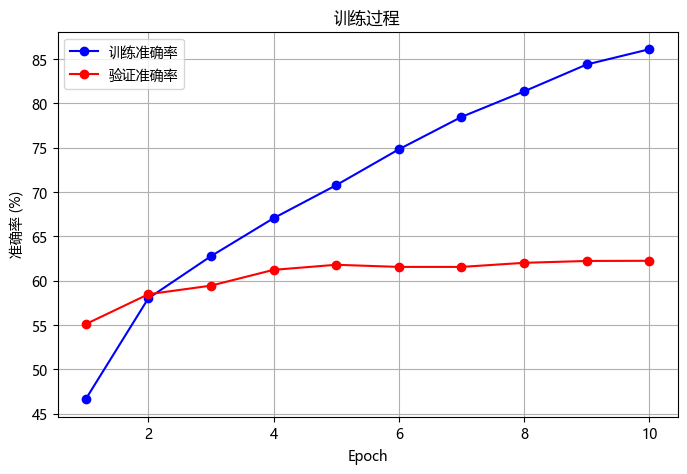

训练准确率一直涨，验证准确率第5轮后停了 → 过拟合（模型开始背答案）
FER2013 人类标注准确率约65%，62%属于正常水平


In [11]:
### Cell 6：查看训练结果
# 如果你想手动记录结果，可以把上面打印的数字填进来
# 下面是示例（用你自己的数据替换）

train_accs = [46.65, 58.02, 62.77, 67.05, 70.77, 74.81, 78.46, 81.34, 84.37, 86.09]
val_accs   = [55.11, 58.48, 59.45, 61.23, 61.80, 61.56, 61.56, 62.02, 62.23, 62.25]

plt.rcParams['font.family'] = 'Microsoft YaHei'  # 微软雅黑，支持中文
plt.rcParams['axes.unicode_minus'] = False        # 负号正常显示

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), train_accs, 'b-o', label='训练准确率')
plt.plot(range(1, 11), val_accs, 'r-o', label='验证准确率')
plt.xlabel('Epoch')
plt.ylabel('准确率 (%)')
plt.title('训练过程')
plt.legend()
plt.grid(True)
plt.show()

print("训练准确率一直涨，验证准确率第5轮后停了 → 过拟合（模型开始背答案）")
print("FER2013 人类标注准确率约65%，62%属于正常水平")